# Matter, NSI, and Lorentz-invariance violation

Constant-density matter, and two kinds of new physics. Each is a different Hamiltonian passed to the same routine — which is the point the library is built around.

In [1]:
import sys
import os

# Works whether or not the package is installed: these notebooks sit one
# level below the repository root, so src/ is one directory up.
sys.path.insert(0, os.path.abspath(os.path.join('..', 'src')))

import numpy as np
import matplotlib.pyplot as plt

import globaldefs as gd
import oscprob2nu
import oscprob3nu
import oscprob4nu
import hamiltonians2nu
import hamiltonians3nu
import hamiltonians4nu

%matplotlib inline
plt.rcParams.update({'figure.figsize': (7.2, 4.2), 'figure.dpi': 90,
                     'axes.grid': True, 'grid.alpha': 0.3,
                     'font.size': 11, 'legend.frameon': False,
                     # Axes end exactly at the data: no padding beyond
                     # x_min/x_max or y_min/y_max.
                     'axes.xmargin': 0.0, 'axes.ymargin': 0.0})

# The three-flavor vacuum Hamiltonian at the NuFit best fit, normal ordering.
# It is energy-independent; dividing by the energy is what the builders do.
H_VAC_3NU = hamiltonians3nu.hamiltonian_3nu_vacuum_energy_independent(
    gd.S12_NO_BF, gd.S23_NO_BF, gd.S13_NO_BF, gd.DCP_NO_BF,
    gd.D21_NO_BF, gd.D31_NO_BF)

KM = gd.CONV_KM_TO_INV_EV      # multiply a length in km to get eV^-1
GEV = 1.0e9                    # multiply an energy in GeV to get eV

## Matter of constant density

Adding the charged-current potential $V_{CC}$ to the $ee$ entry produces the MSW resonance: a peak in $P_{e\mu}$ at the energy where the matter term cancels the vacuum one.

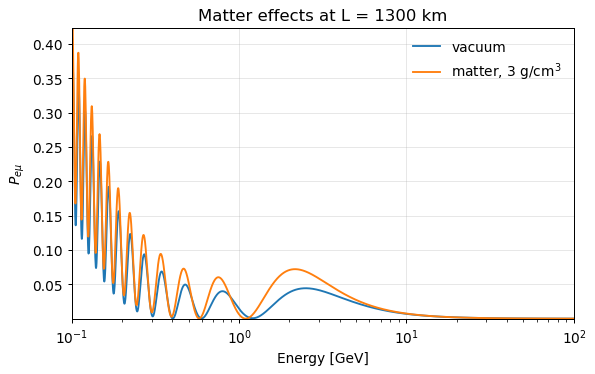

In [2]:
E_gev = np.logspace(-1.0, 2.0, 2000)
L = 1300.0*KM

H_vac = np.asarray(H_VAC_3NU)/(E_gev[:, None, None]*GEV)
H_mat = hamiltonians3nu.hamiltonian_3nu_matter(
    H_VAC_3NU, E_gev*GEV, gd.VCC_EARTH_CRUST)

p_vac = oscprob3nu.probabilities_3nu(H_vac, L)
p_mat = oscprob3nu.probabilities_3nu(H_mat, L)

fig, ax = plt.subplots()
ax.semilogx(E_gev, p_vac[:, 1], label="vacuum")
ax.semilogx(E_gev, p_mat[:, 1], label="matter, 3 g/cm$^3$")
ax.set_xlabel("Energy [GeV]")
ax.set_ylabel(r"$P_{e\mu}$")
ax.set_title("Matter effects at L = 1300 km")
ax.legend()
plt.show()

The builders take an **array** of energies and return one Hamiltonian per energy, stacked. That is why the matter curve above needed no loop.

## Non-standard interactions

A non-standard interaction (NSI) is a hypothetical extra neutrino–matter coupling. It enters as a potential with its own flavor structure, written relative to $V_{CC}$ as a matrix of dimensionless strengths $\epsilon_{\alpha\beta}$:

$$ H = H_{\rm vac} + V_{CC}\begin{pmatrix}1 + \epsilon_{ee} & \epsilon_{e\mu} & \epsilon_{e\tau} \\\epsilon_{e\mu}^* & \epsilon_{\mu\mu} & \epsilon_{\mu\tau} \\\epsilon_{e\tau}^* & \epsilon_{\mu\tau}^* & \epsilon_{\tau\tau}\end{pmatrix} $$

The `1` recovers standard matter when every $\epsilon$ vanishes. `globaldefs` carries an illustrative set — these are the values the curve below actually uses, not a fit to anything:

In [3]:
names = ["eps_ee", "eps_emu", "eps_etau",
         "eps_mumu", "eps_mutau", "eps_tautau"]
for n, v in zip(names, gd.EPS_3):
    print("  %-11s = %s" % (n, v))

  eps_ee      = 0.06
  eps_emu     = -0.06
  eps_etau    = 0.0
  eps_mumu    = 1.2
  eps_mutau   = 0.0
  eps_tautau  = 0.0


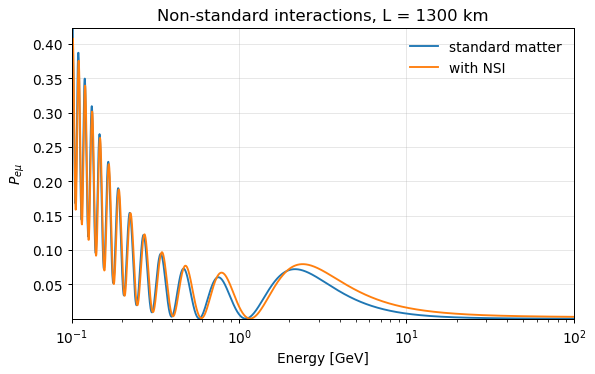

In [4]:
H_nsi = hamiltonians3nu.hamiltonian_3nu_nsi(
    H_VAC_3NU, E_gev*GEV, gd.VCC_EARTH_CRUST, gd.EPS_3)
p_nsi = oscprob3nu.probabilities_3nu(H_nsi, L)

fig, ax = plt.subplots()
ax.semilogx(E_gev, p_mat[:, 1], label="standard matter")
ax.semilogx(E_gev, p_nsi[:, 1], label="with NSI")
ax.set_xlabel("Energy [GeV]")
ax.set_ylabel(r"$P_{e\mu}$")
ax.set_title("Non-standard interactions, L = 1300 km")
ax.legend()
plt.show()

## Lorentz-invariance violation

A CPT-odd Lorentz-invariance-violating (LIV) background couples to neutrinos through a term that is *added* to the Hamiltonian with its own mixing structure. The physically important point is the energy dependence: the vacuum term falls as $1/E$ and this one does not, so it is invisible at low energy and dominant at high energy — which is why the curve below only separates at the right-hand end.

The parameters below are illustrative defaults from `globaldefs`, shown because a plot of "LIV" means nothing without them:

In [5]:
print("mixing, as sin(xi):")
for n, v in (("sin(xi12)", gd.SXI12), ("sin(xi23)", gd.SXI23),
             ("sin(xi13)", gd.SXI13)):
    print("  %-10s = %.3f" % (n, v))
print("phase  : %.3f rad" % gd.DXICP)
print("eigenvalues b1, b2, b3 : %.1e, %.1e, %.1e"
      % (gd.B1, gd.B2, gd.B3))
print("scale  Lambda          : %.1e eV" % gd.LAMBDA)

mixing, as sin(xi):
  sin(xi12)  = 0.000
  sin(xi23)  = 0.000
  sin(xi13)  = 0.000
phase  : 0.000 rad
eigenvalues b1, b2, b3 : 1.0e-09, 1.0e-09, 2.0e-09
scale  Lambda          : 1.0e+12 eV


Two things in that list are worth reading rather than skipping past, and they are the reason it is printed at all.

The LIV mixing angles are all **zero**, so the rotation is the identity and the added term is simply

$$ \frac{E}{\Lambda}\,\mathrm{diag}(b_1, b_2, b_3) $$

in the flavor basis — a background that shifts the flavor eigenvalues without introducing any mixing of its own. That is the simplest non-trivial case, and it is enough to move the curve. And since $b_1 = b_2$ here, only the difference $b_3 - b_1$ survives dropping the trace; a common $b$ would do nothing at all.

The energy dependence is the signature. The vacuum term falls as $1/E$ while this one *rises* as $E$, so there is a crossover where they are equal, at

$$ E_\times = \sqrt{\frac{\Delta m^2_{31}\Lambda}{2b_3}} \approx 0.8~\mathrm{GeV} $$

for these values. Below it the vacuum term wins and the curve is the ordinary one; above it the LIV term takes over, and by 100 GeV it is four orders of magnitude larger. That growth with energy is what makes high-energy neutrinos the place to look for this kind of physics.

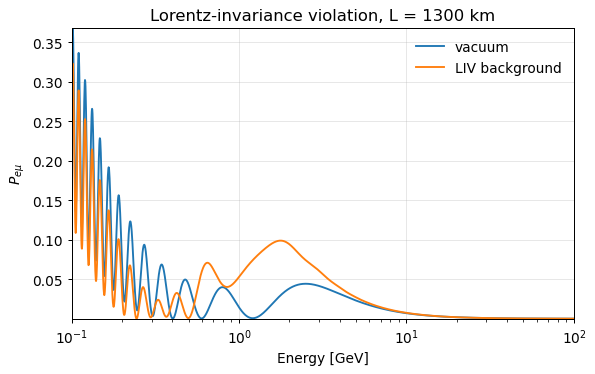

In [6]:
H_liv = hamiltonians3nu.hamiltonian_3nu_liv(
    H_VAC_3NU, E_gev*GEV, gd.SXI12, gd.SXI23, gd.SXI13,
    gd.DXICP, gd.B1, gd.B2, gd.B3, gd.LAMBDA)
p_liv = oscprob3nu.probabilities_3nu(H_liv, L)

fig, ax = plt.subplots()
ax.semilogx(E_gev, p_vac[:, 1], label="vacuum")
ax.semilogx(E_gev, p_liv[:, 1], label="LIV background")
ax.set_xlabel("Energy [GeV]")
ax.set_ylabel(r"$P_{e\mu}$")
ax.set_title("Lorentz-invariance violation, L = 1300 km")
ax.legend()
plt.show()

---

**Previous:** [Oscillations in vacuum](02_vacuum_oscillations.ipynb)  
**Next:** [Oscillograms](04_oscillogram.ipynb) --- a two-dimensional map in a single call  
[API reference](https://mbustama.github.io/NuOscProbExact/functions.html) &middot; [Numerical recipes](https://mbustama.github.io/NuOscProbExact/recipes.html) &middot; [All notebooks](.)